# 📊 Customer Churn Prediction

## 🔎 Overview

This project builds and evaluates machine learning models to predict whether a telecommunications customer is likely to **churn** (leave the company) based on their demographic information, services, contract details, and billing information.

The project focuses on **tree-based machine learning algorithms** and compares their performance:

- 🌳 **Decision Tree** — a single tree that learns decision rules from the data.
- 🌲 **Random Forest** — an ensemble of multiple decision trees whose predictions are combined.
- 🚀 **XGBoost** — a gradient-boosting algorithm that builds trees sequentially to improve previous predictions.

## 🎯 Project Objectives

The main objectives of this project are to:

1. 🧹 Explore and understand the Telco Customer Churn dataset.
2. 🔧 Clean and preprocess the data.
3. 📈 Perform exploratory data analysis (EDA).
4. ⚙️ Prepare categorical and numerical features for machine learning.
5. 🌳 Train a baseline Decision Tree model.
6. 🛡️ Analyze and control overfitting using tree hyperparameters.
7. 🔍 Tune the Decision Tree using cross-validation.
8. 🌲 Train and tune a Random Forest model.
9. 🚀 Train and tune an XGBoost model.
10. 📊 Compare the models using appropriate classification metrics.
11. 📉 Analyze ROC-AUC and Precision-Recall curves.
12. 🔬 Use SHAP to explain the predictions of the selected model.
13. 💾 Save the final model for later deployment.

## 📏 Model Evaluation

Because customer churn is a binary classification problem and the classes are imbalanced, **accuracy alone is not sufficient** to evaluate the models.

We will therefore consider:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix

Special attention will be given to the **Churn** class because correctly identifying customers who are likely to leave is an important part of the problem.

## 💼 Business Goal

The final business goal is to build a model that can help a telecommunications company **identify customers at higher risk of churn early enough to take appropriate retention actions**.

The model can support the business by:

- 🎯 Identifying customers who may be at higher risk of leaving.
- 📣 Helping prioritize customers for retention campaigns.
- 🔎 Providing insights into the factors associated with the model's churn predictions.
- 💡 Supporting more targeted use of customer-retention resources.

The model is intended to **support business decision-making**, rather than automatically determine which customers should receive a particular intervention.

## 🧠 Machine Learning Workflow

```text
Data Loading
     ↓
Data Cleaning
     ↓
Exploratory Data Analysis
     ↓
Feature Engineering & Encoding
     ↓
Train/Test Split
     ↓
Baseline Decision Tree
     ↓
Hyperparameter Tuning
     ↓
Random Forest
     ↓
XGBoost
     ↓
Model Comparison
     ↓
SHAP Explainability
     ↓
Final Model
     ↓
Model Saving & Deployment 🚀


## 📂 Dataset

The project uses the **Telco Customer Churn** dataset, where each row represents a customer and the target variable indicates whether the customer churned.

The target variable is:

* `Churn = Yes` → Customer churned
* `Churn = No` → Customer did not churn

The dataset contains information related to customer demographics, account information, subscribed services, contract type, tenure, and charges.


---













## 1. Setup


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split ,GridSearchCV ,StratifiedKFold ,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import(
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    f1_score, precision_score, recall_score, 
)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
import json
import platform
from pathlib import Path
from datetime import datetime, timezone
import sklearn
import joblib
import shap
from scipy.special import expit

RANDOM_STATE = 42
pd.set_option("display.max_columns",None)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 3. Explore the Dataset

how imbalanced is the target?

Before modelling, we check how the two classes are distributed. Class balance decides which metrics we can trust: if most customers stay, a model can look accurate just by never predicting churn.

- `value_counts()` counts customers per class; `normalize=True` gives shares instead of counts.
- `.sort_index()` keeps the order 0, 1, so the plot labels always match the bars.
- The last print line shows the accuracy of a model that always predicts "stayed". Any real model has to beat this baseline.

This is only a preview of what the tree will discover on its own: a tall bar hints at a yes/no question that separates churners from stayers. Nothing is fitted here.

In [3]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No        

In [4]:
print(df.shape)


(7043, 21)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [10]:
df["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str

In [11]:
df["customerID"].duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
df.select_dtypes(include="str").columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

## 4. Data Cleaning

`TotalCharges` should be numeric, but pandas read it as text. That happens when even one value can't be parsed as a number, so the whole column falls back to `str`.

We investigate before fixing, because the right fix depends on *why* those values are bad:

- `pd.to_numeric(..., errors="coerce")` tries to convert every value. Anything it can't parse becomes `NaN` instead of raising an error. That makes the bad rows easy to find.
- `.map(repr)` shows the raw value with quotes, so invisible characters like a blank space become visible.
- We also print `tenure`, `MonthlyCharges` and `Churn` for those rows, to look for a pattern.

In [14]:
total_numeric = pd.to_numeric(df["TotalCharges"],errors="coerce")
bad_rows = df[total_numeric.isna()]
print("Rows that failed to convert:",len(bad_rows))
print("Raw values:",bad_rows["TotalCharges"].map(repr).unique().tolist())
bad_rows[["customerID","tenure","MonthlyCharges","TotalCharges","Churn"]]

Rows that failed to convert: 11
Raw values: ["' '"]


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


## 5. Apply the cleaning

The output above shows that the blank `TotalCharges` values belong to customers with `tenure == 0`: they have not been billed yet, so their true total is **0**, not "unknown". We fill them with 0 instead of removing the rows. This keeps those customers, and the model also sees what a brand-new customer looks like, which matters when it predicts on new customers later.

Three cleaning actions:

1. **`TotalCharges`**: convert to numbers with `pd.to_numeric`, then fill the blanks with 0. A safety check first confirms that every blank belongs to a `tenure == 0` customer.
2. **`customerID`**: drop it. It is unique per row, so there is no pattern to learn, and a deep tree could use it to memorize training rows.
3. **`Churn`**: map `No → 0` and `Yes → 1`. Metrics like recall and ROC-AUC need a clear "positive" class, and here churn = 1.

Finally we verify: no missing values left and the expected dtypes.

In [15]:
total_numeric = pd.to_numeric(df["TotalCharges"],errors="coerce")
blank_mask = total_numeric.isna()
assert (df.loc[blank_mask,"tenure"]==0).all()
print("Blank TotalCharges:",blank_mask.sum(),"|Customers with tenure == 0:",(df["tenure"]==0).sum())
df["TotalCharges"] = total_numeric.fillna(0.0)
df = df.drop(columns="customerID")
df["Churn"] = df["Churn"].map({'No':0 , 'Yes':1})

Blank TotalCharges: 11 |Customers with tenure == 0: 11


In [16]:
print("Shape:",df.shape)
print("Missing Values:",df.isna().sum().sum())
print(df.dtypes.value_counts())

Shape: (7043, 20)
Missing Values: 0
str        15
int64       3
float64     2
Name: count, dtype: int64


## 5. Exploratory Data Analysis

churn rate by category

Because `Churn` is now 0/1, its mean inside a group is that group's churn rate. `groupby(col)["Churn"].mean()` gives one rate per category, and we plot it for three features.

This is only a preview of what the tree will discover on its own: a tall bar hints at a yes/no question that separates churners from stayers. Nothing is fitted here.

numeric features by churn

We compare how `tenure` and `MonthlyCharges` are distributed for stayed vs churned customers. `density=True` normalizes each histogram to the same total area, so the two classes are comparable even though they have very different sizes.

A tree splits numeric features with thresholds (for example `tenure <= 12`). Where the two histograms differ most is where such a threshold is likely to help.

### 5.1 Churn Distribution

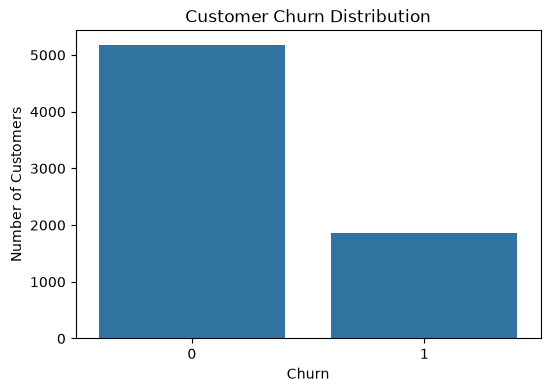

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### 5.2 Churn vs Contract

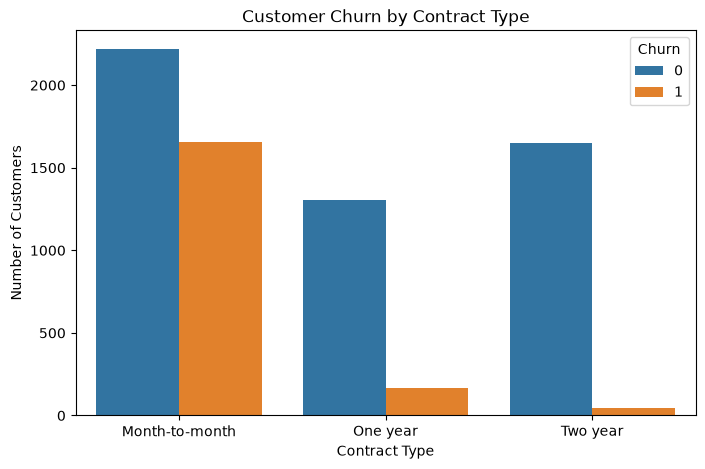

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Contract",hue="Churn")
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

### 5.3 Churn vs Ternue

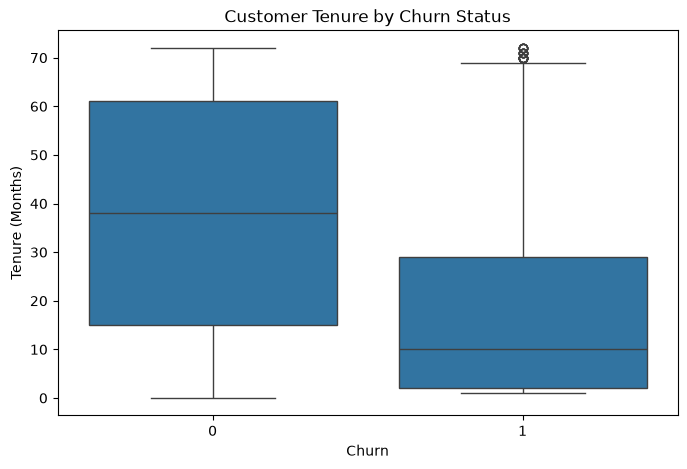

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Churn",y="tenure")
plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### 5.4 Churn vs Monthly Charges

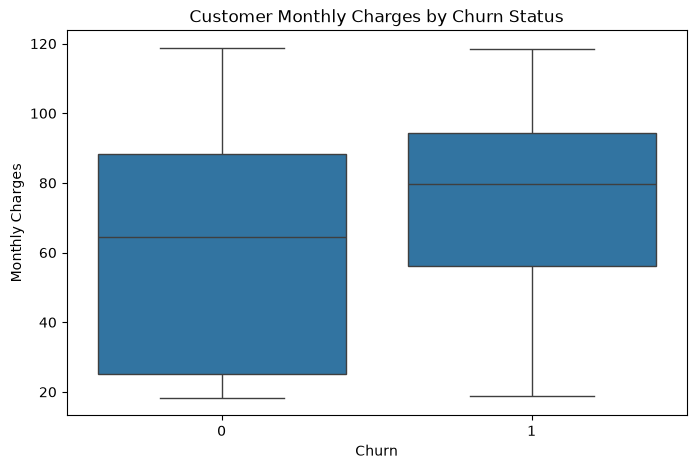

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Churn",y="MonthlyCharges")
plt.title("Customer Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

### 5.5 Churn vs Internet Service

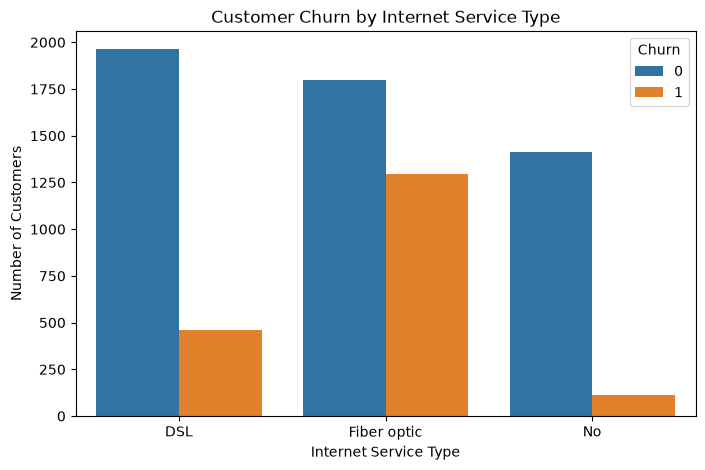

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="InternetService",hue="Churn")
plt.title("Customer Churn by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")
plt.show()

## 6. Train/test split

We separate the features `X` (all columns except `Churn`) from the target `y`, then hold out 20% of the customers as a **test set**. The test set plays the role of new, unseen customers and stays untouched until the final evaluation.

- `train_test_split` shuffles the rows using `random_state`, then cuts them 80/20.
- `stratify=y` makes the cut inside each class, so the train and test sets keep the same churn share. This matters with imbalanced classes.
- There is no separate validation set here. Later, cross-validation on the training set does that job.

The last two prints check the sizes and that the churn share is the same in both sets.

In [22]:
X = df.drop(columns="Churn")
y = df["Churn"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=RANDOM_STATE)
print("Train:",X_train.shape,"| Test:",X_test.shape)
print("Churn share train:",round(y_train.mean(),3)) 
print("Churn share test:",round(y_test.mean(),3)) 

Train: (5634, 19) | Test: (1409, 19)
Churn share train: 0.265
Churn share test: 0.265


## 7. Preprocessing: one-hot encoding

scikit-learn trees need numbers, not text, so each category becomes its own 0/1 column (the one-hot encoding from the course lab). A `ColumnTransformer` applies a different treatment to each group of columns:

- **Numeric columns** pass through unchanged. Trees only compare values to thresholds, so scaling is not needed (unlike the neural network).
- **Text columns** go through `OneHotEncoder`:
  - `drop="if_binary"`: a Yes/No column becomes one 0/1 column instead of two redundant ones.
  - `handle_unknown="ignore"`: a category never seen in training becomes all zeros instead of raising an error.
  - `sparse_output=False`: returns a regular dense array.
- `verbose_feature_names_out=False` keeps clean column names, like `Contract_One year`.

`select_dtypes(exclude="number")` picks the text columns, whether pandas calls them `object` or `str`. This cell only defines the recipe; nothing is learned yet.

In [25]:
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = X_train.select_dtypes(exclude="number").columns.tolist()
print("Numeric: ",numeric_cols)
print("Categorical: ",categorical_cols)
preprocessor = ColumnTransformer(
    transformers = [
    ("num","passthrough",numeric_cols),
    ("cat",OneHotEncoder(drop="if_binary",handle_unknown="ignore",sparse_output=False),categorical_cols)
    ],
    verbose_feature_names_out=False
)


Numeric:  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 8. Fit on the training set, transform both sets

- `fit_transform(X_train)`: `fit` learns which categories exist, then `transform` builds the 0/1 columns.
- `transform(X_test)`: applies the same recipe to the test set without learning anything new.
- `get_feature_names_out()` returns the names of the new columns, in order.

The printed shapes show how many columns the encoding created. The table shows the first three customers in encoded form, transposed so each row is one feature.

In [26]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print("Before:",X_train.shape,"| After:",X_train_enc.shape)
pd.DataFrame(X_train_enc, columns=feature_names).head(3).T

Before: (5634, 19) | After: (5634, 40)


,0,1,2
SeniorCitizen,0.00,0.00,0.00
tenure,35.00,15.00,13.00
MonthlyCharges,49.20,75.10,40.55
TotalCharges,1701.65,1151.55,590.35
gender_Male,1.00,1.00,1.00
Partner_Yes,0.00,1.00,1.00
Dependents_Yes,0.00,1.00,1.00
PhoneService_Yes,0.00,1.00,0.00
MultipleLines_No,0.00,1.00,0.00
MultipleLines_No phone service,1.00,0.00,1.00


## 9. A first decision tree

Time to bring in the model you already know the theory for. `DecisionTreeClassifier` implements the same idea as your Andrew Ng lab (best-split search using information gain), just optimized in C and wrapped in a scikit-learn API.

The functions you wrote map onto scikit-learn methods like this:

| Your lab function | scikit-learn equivalent |
|---|---|
| `compute_entropy` | used internally at every split |
| `split_dataset` | used internally at every split |
| `compute_information_gain` | used internally to pick the best feature/threshold |
| `get_best_split` | used internally, at every node |
| `build_tree_recursive` | `.fit(X, y)` |
| walking the tree to classify one example | `.predict(X)` |

We start with `max_depth=4`: shallow on purpose, so the tree is still small enough to plot and read by eye before we tune it properly.

- `.fit(X_train_enc, y_train)` grows the tree.
- `.predict(X_test_enc)` walks new customers down the tree and returns 0/1.

In [27]:
tree_clf = DecisionTreeClassifier(max_depth=4,random_state=RANDOM_STATE)
tree_clf.fit(X_train_enc,y_train)
y_pred = tree_clf.predict(X_test_enc)
print("Tree Depth reached:",tree_clf.get_depth())
print("Number of leaves:",tree_clf.get_n_leaves())

Tree Depth reached: 4
Number of leaves: 16


## 10. Evaluate: beyond accuracy

Now we bring in the metrics that actually matter for an imbalanced target.

- `classification_report`: precision, recall and F1 per class. Watch the **Churned** row, since that's the class the "always predict stayed" baseline gets completely wrong.
- `confusion_matrix`: counts of correct/incorrect predictions per class.
  - top-left = correctly predicted "stayed"
  - bottom-right = correctly predicted "churned" (true positives — customers we correctly flag as at risk)
  - bottom-left = churners we missed (false negatives — the costly error for a churn-prevention team)
- `predict_proba(X)[:, 1]` gives the tree's estimated *probability* of churn, instead of a hard 0/1. This lets us compute:
  - **ROC-AUC**: how well the model ranks churners above stayers, across every possible threshold
  - **PR-AUC**: like ROC-AUC, but focused on the minority class, so it's the more informative one when classes are imbalanced

              precision    recall  f1-score   support

      Stayed       0.82      0.91      0.87      1035
     Churned       0.66      0.45      0.54       374

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



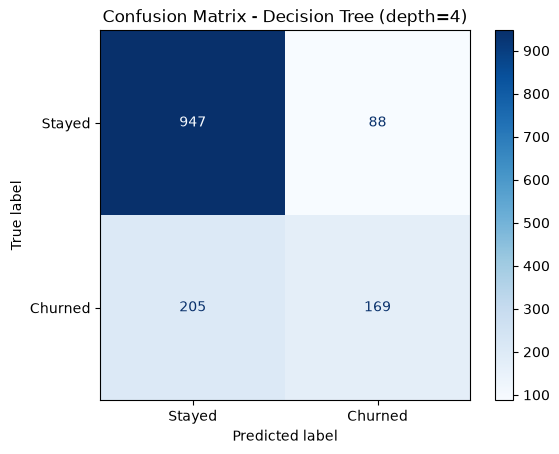

ROC-AUC: 0.829
PR-AUC:  0.601


In [28]:
y_prob = tree_clf.predict_proba(X_test_enc)[:,1]
print(classification_report(y_test,y_pred,target_names=["Stayed","Churned"]))
cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=["Stayed","Churned"]).plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree (depth=4)")
plt.show()
print(f"ROC-AUC: {roc_auc_score(y_test,y_prob):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test,y_prob):.3f}")

### 10.1 ROC and Precision-Recall curves

Two more views of the same probabilities, this time across all thresholds at once rather than one number:

- **ROC curve**: true positive rate vs false positive rate. The dashed diagonal is a model that guesses randomly; the further above it, the better.
- **Precision-Recall curve**: precision vs recall for the churned class. On imbalanced data this curve is more informative than ROC, since it ignores the (large, easy) "stayed" class.

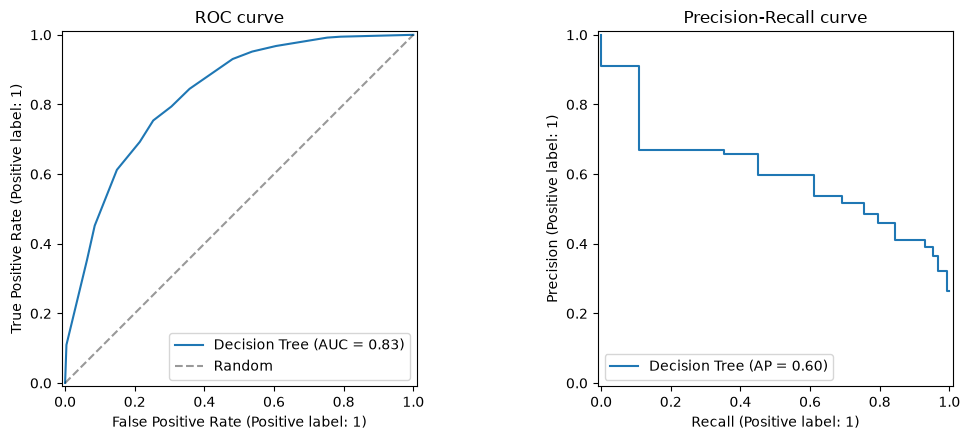

In [29]:
fig,axes = plt.subplots(1,2,figsize=(11,4.5))
RocCurveDisplay.from_predictions(y_test,y_prob,ax=axes[0],name="Decision Tree")
axes[0].plot([0,1],[0,1],"k--",alpha=0.4,label="Random")
axes[0].set_title("ROC curve")
axes[0].legend()
PrecisionRecallDisplay.from_predictions(y_test,y_prob,ax=axes[1],name="Decision Tree")
axes[1].set_title("Precision-Recall curve")
plt.tight_layout()
plt.show()

## 11. Visualize the tree

At depth 4 the tree is still small enough to read directly. `plot_tree` draws every node with its splitting question, its Gini impurity (how mixed the node is: 0 means pure), how many training customers reached it, and which class it predicts.

- `filled=True`: colors each node by its predicted class, darker = more pure
- `feature_names`: labels the splits with real column names instead of `X[12]`

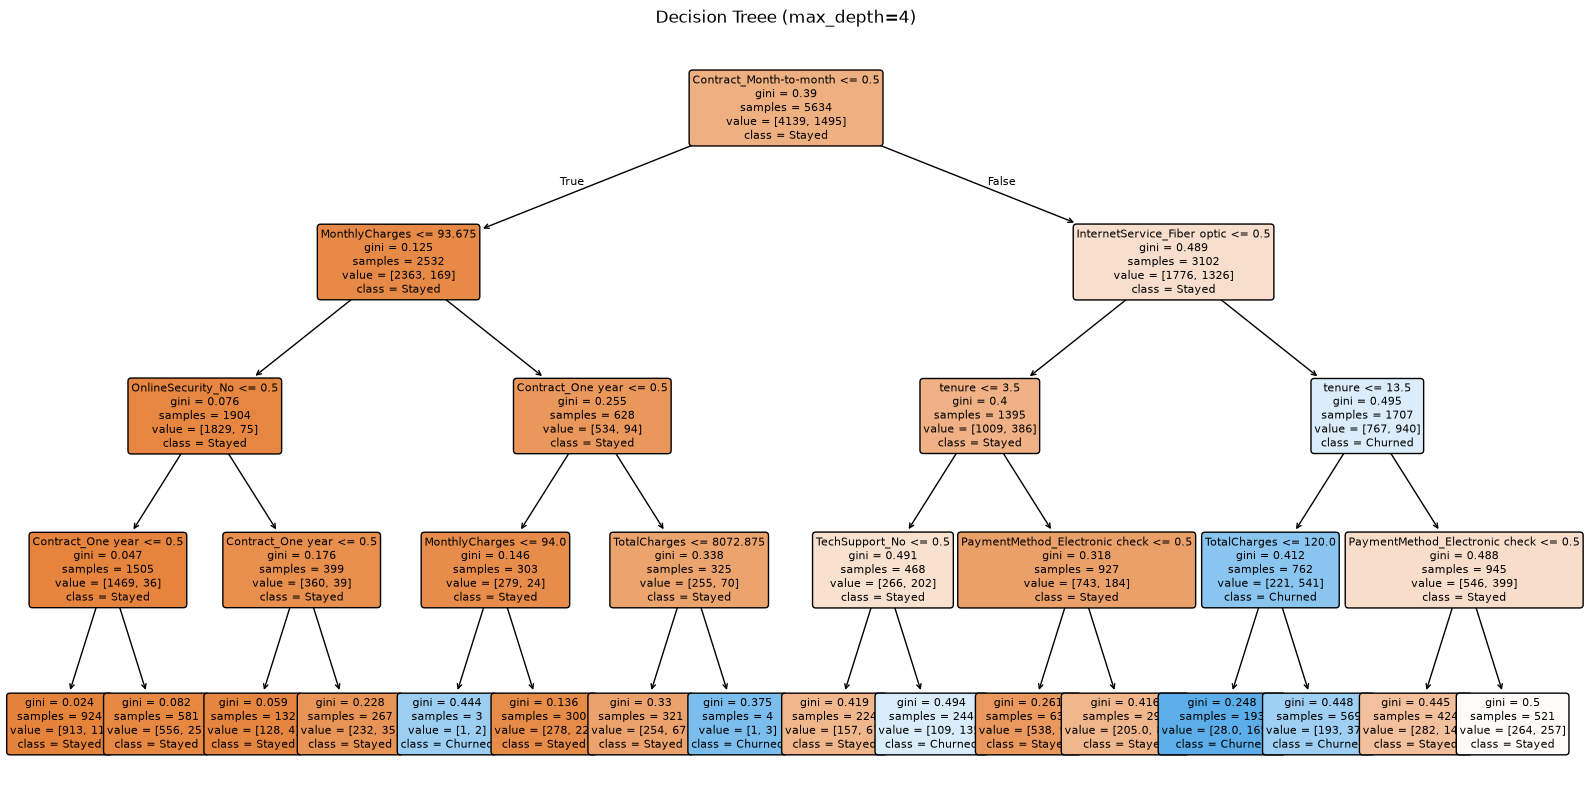

In [30]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_clf,
    feature_names=feature_names,
    class_names=["Stayed","Churned"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Treee (max_depth=4)")
plt.show()

### 11.1 Feature Importance

`feature_importances_` scores every feature by how much it reduced impurity across the whole tree, summed over every split that used it and weighted by how many customers passed through that split. It's a single global summary, unlike the tree plot which shows structure.

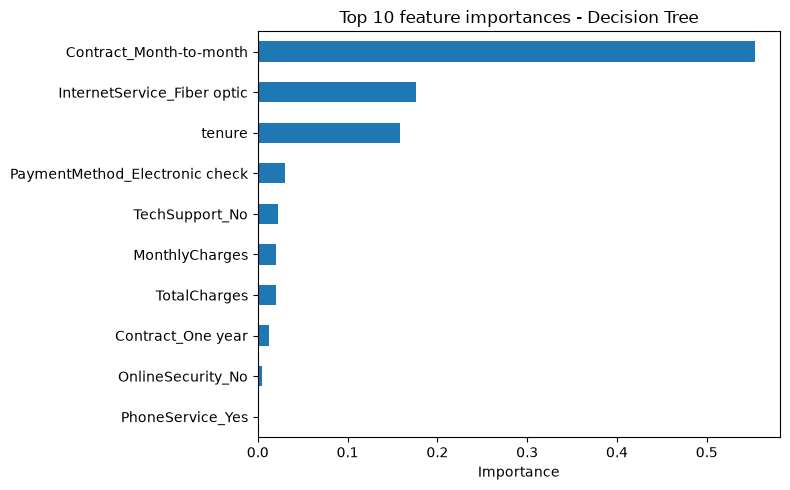

In [31]:
importances = pd.Series(tree_clf.feature_importances_, index=feature_names)
top_importances = importances.sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
top_importances.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 10 feature importances - Decision Tree")
plt.tight_layout()
plt.show()

## 12. Tune the tree with cross-validation

`max_depth=4` was a guess. Now we search over a grid of hyperparameters properly, using cross-validation instead of the test set, so the test set stays untouched until the very end.

- `param_grid`: the combinations to try.
  - `max_depth`: how deep the tree can grow (`None` = unlimited, until nodes are pure)
  - `min_samples_leaf`: a leaf must have at least this many customers, which is a second brake against overfitting
  - `class_weight="balanced"`: makes mistakes on the minority class (churners) count more during training, which directly targets our recall problem
- `StratifiedKFold(n_splits=5, ...)`: splits `X_train` into 5 folds, each keeping the same churn ratio. The model trains on 4 folds and validates on the 5th, five times, rotating which fold is held out.
- `GridSearchCV`: tries every combination, scores each with `scoring="f1"` (the metric we actually care about, not accuracy), and keeps the best.
- `n_jobs=-1`: uses all CPU cores, since a grid search fits many trees.

This is the automated version of the manual F1-tuning you did in the lab.

In [32]:
param_grid = {
    "max_depth": [3,4,5,6,8,10,None],
    "min_samples_leaf": [1,5,10,20,50],
    "class_weight": [None,"balanced"]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
grid_search.fit(X_train_enc,y_train)
print("Best params:",grid_search.best_params_)
print(f"Best CV F1:{grid_search.best_score_:.3f}")
best_tree = grid_search.best_estimator_

Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 50}
Best CV F1:0.626


## 13. Evaluate the tuned tree on the test set

This is the first and only time the test set is used for anything other than the split itself. It gives an honest read of how the tuned tree performs on customers it has never influenced in any way — not training, not the grid search.

We reuse the exact same metrics as step 13, so the two trees compare directly.

              precision    recall  f1-score   support

      Stayed       0.91      0.73      0.81      1035
     Churned       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.831
PR-AUC:  0.621


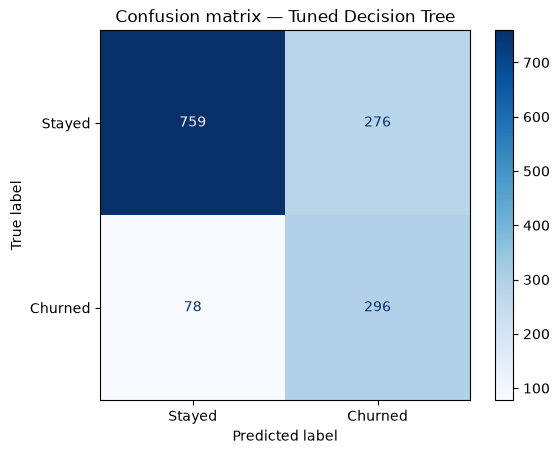

In [33]:
y_pred_best = best_tree.predict(X_test_enc)
y_proba_best = best_tree.predict_proba(X_test_enc)[:, 1]

print(classification_report(y_test, y_pred_best, target_names=["Stayed", "Churned"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_proba_best):.3f}")

cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(cmap="Blues")
plt.title("Confusion matrix — Tuned Decision Tree")
plt.show()

## 14. Visualize the tuned tree

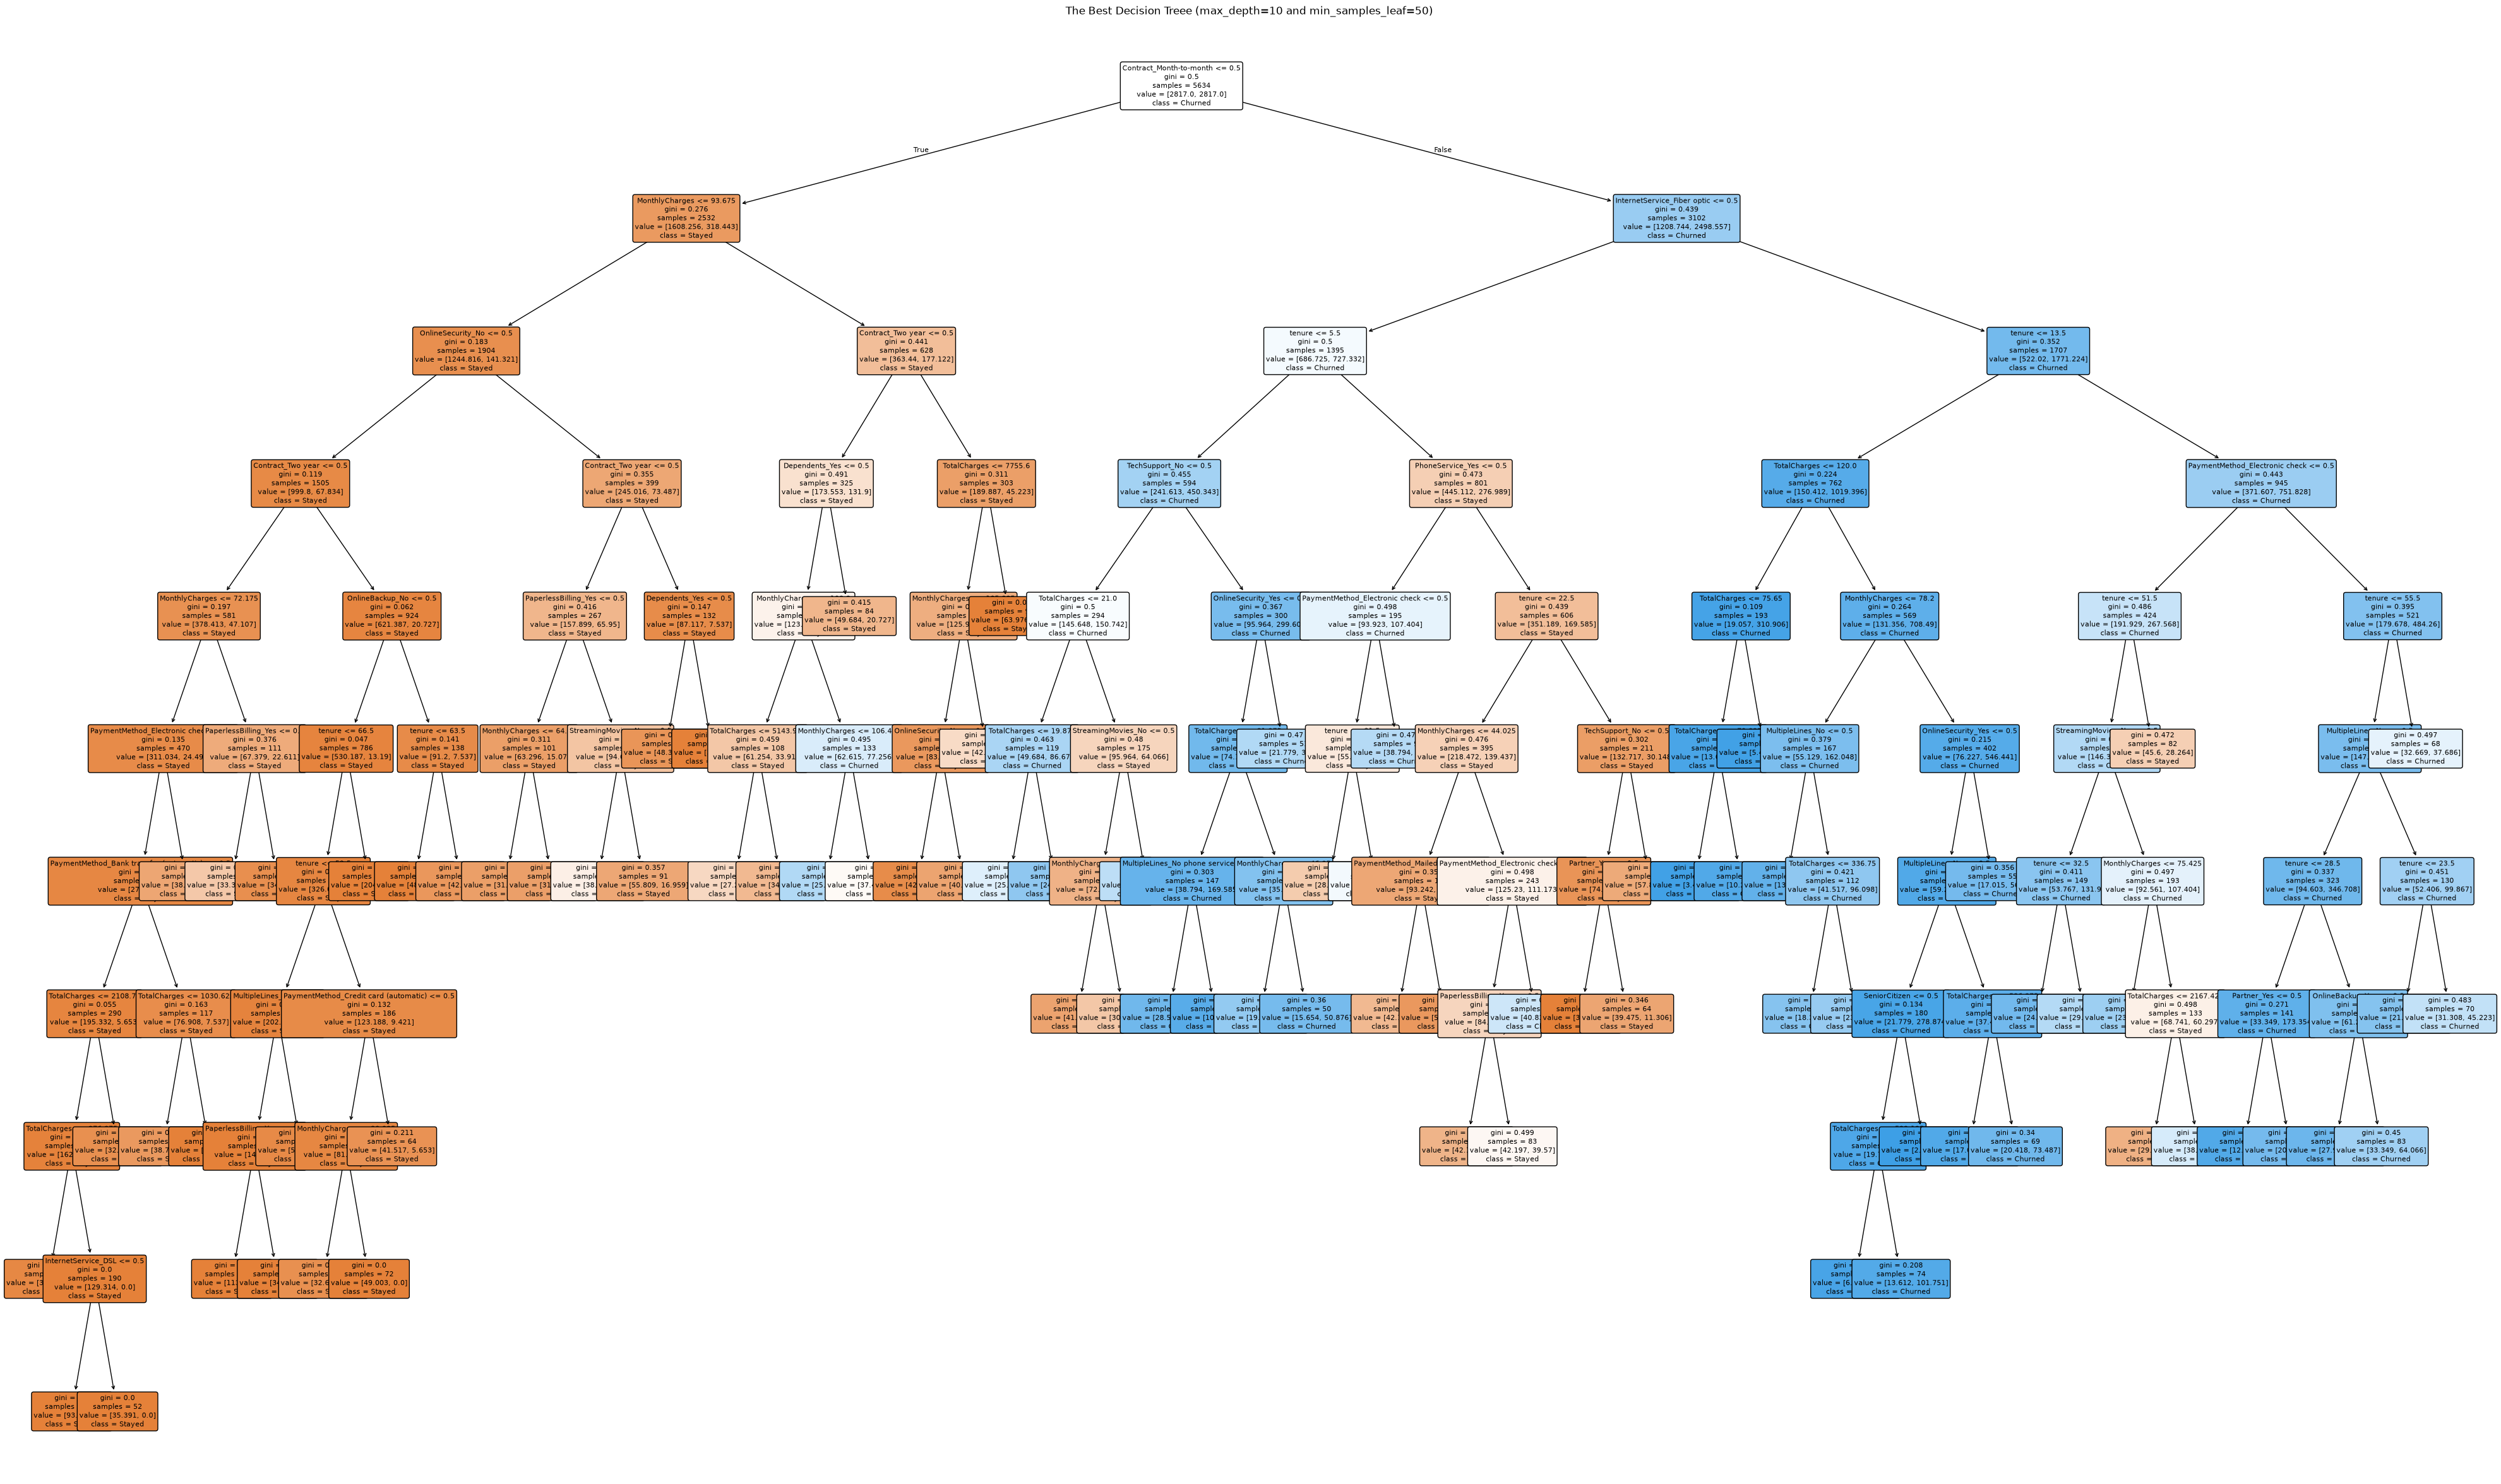

In [34]:
plt.figure(figsize=(50,30))
plot_tree(
    best_tree,
    feature_names=feature_names,
    class_names=["Stayed","Churned"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("The Best Decision Treee (max_depth=10 and min_samples_leaf=50)")
plt.show()

## 15. Random Forest

A Random Forest trains many trees and lets them vote (classification = majority vote). Each tree is deliberately made different in two ways, so their mistakes don't all point the same direction:

- **Bagging**: each tree trains on a random sample of customers, drawn *with replacement* from the training set.
- **Feature randomness**: at each split, each tree only considers a random subset of features (`max_features`) instead of all of them.

That combination is what separates a forest from just fitting the same tree 300 times.

New hyperparameters:
- `n_estimators`: how many trees to grow
- `max_features`: how many features each split may consider (`"sqrt"` = √40 ≈ 6 features per split here)
- `max_depth`, `min_samples_leaf`, `class_weight`: same meaning as for the single tree

**`RandomizedSearchCV` instead of `GridSearchCV`**: with 5 hyperparameters, trying every combination would mean fitting thousands of forests. `RandomizedSearchCV` instead samples `n_iter` random combinations, which is far faster and, past a certain grid size, usually finds a similarly good result. `n_jobs=-1` trains across all your CPU cores at once — this step is the one most worth walking away from while it runs.

In [35]:
param_dist = {
    "n_estimators":[200,300,500],
    "max_depth":[None,10,15,20],
    "min_samples_leaf":[1,5,10,20],
    "max_features":["sqrt","log2"],
    "class_weight":[None,"balanced"]
}
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
random_search.fit(X_train_enc,y_train)
print("Best params:",random_search.best_params_)
print(f"Best CV F1: {random_search.best_score_:.3f}")
best_forest = random_search.best_estimator_

Best params: {'n_estimators': 500, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}
Best CV F1: 0.635


### 15.1 Evaluate the best forest tree

Same evaluation as the tuned tree in step 18, so the two are directly comparable on the same held-out customers.

              precision    recall  f1-score   support

      Stayed       0.90      0.75      0.82      1035
     Churned       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC: 0.841
PR-AUC:  0.647


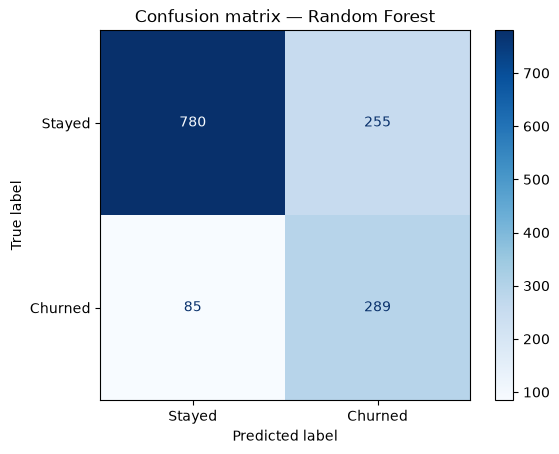

In [36]:
y_pred_forest = best_forest.predict(X_test_enc)
y_proba_forest = best_forest.predict_proba(X_test_enc)[:, 1]

print(classification_report(y_test, y_pred_forest, target_names=["Stayed", "Churned"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_forest):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_proba_forest):.3f}")

cm = confusion_matrix(y_test, y_pred_forest)
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(cmap="Blues")
plt.title("Confusion matrix — Random Forest")
plt.show()

## 16. XGBoost : boosting instead of bagging

Random Forest builds 500 independent trees in parallel and averages them (**bagging**). XGBoost instead builds trees one after another (**boosting**): tree 2 focuses on the customers tree 1 got wrong, tree 3 focuses on what's still wrong after trees 1–2, and so on. Each tree is deliberately weak and shallow on its own; the strength comes from the sequence.

New hyperparameters:
- `learning_rate`: how much each new tree corrects the previous ones. Lower = more trees needed, but usually a better final model.
- `subsample` / `colsample_bytree`: the fraction of rows / columns each tree trains on — XGBoost's own version of the randomness that makes a forest robust.
- `scale_pos_weight`: XGBoost has no `class_weight`. Instead, this single number upweights the minority class. The standard choice is `count(negative) / count(positive)`, computed from `y_train`.

We fit `n_jobs=1` on the estimator itself and let `RandomizedSearchCV`'s `n_jobs=-1` handle the parallelism, running many single-threaded fits side by side instead of nesting two levels of parallelism, which fights for the same CPU cores.

In [37]:
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
param_dist_xgb = {
    "n_estimators":[100,200,300,500],
    "max_depth":[3,4,5,6,8],
    "learning_rate":[0.01,0.05,0.1,0.2],
    "subsample":[0.6,0.8,1.0],
    "colsample_bytree":[0.6,0.8,1.0],
    "scale_pos_weight":[1,scale_pos_weight]
}
random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
random_search_xgb.fit(X_train_enc,y_train)
print("Best params:",random_search_xgb.best_params_)
print(f"Best CV F1: {random_search_xgb.best_score_:.3f}")
best_xgb = random_search_xgb.best_estimator_

scale_pos_weight: 2.77
Best params: {'subsample': 1.0, 'scale_pos_weight': np.float64(2.768561872909699), 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV F1: 0.635


## 17. Evaluate : XGBoost on the test set


In [38]:
y_pred_xgb = best_xgb.predict(X_test_enc)
y_prob_xgb = best_xgb.predict_proba(X_test_enc)[:,1]
print(classification_report(y_test, y_pred_xgb, target_names=["Stayed","Churned"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb,):.3f}") 
print(f"PR-AUC: {average_precision_score(y_test, y_prob_xgb,):.3f}")       

              precision    recall  f1-score   support

      Stayed       0.91      0.74      0.82      1035
     Churned       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

ROC-AUC: 0.846
PR-AUC: 0.659


## 18. Compare all the three models

One table, one pair of curves, all on the same test set. `precision_score` / `recall_score` / `f1_score` take `pos_label=1` by default, i.e. the Churned class, which is what we care about.

In [39]:
models = {
    "Decision Tree": best_tree,
    "Random Forest": best_forest,
    "XGBoost": best_xgb
}
rows = [ ]
for name,model in models.items():
    pred = model.predict(X_test_enc)
    proba = model.predict_proba(X_test_enc)[:,1]
    rows.append({
        "Model": name,
        "Precision (Churn)": precision_score(y_test, pred),
        "Recall (Churn)": recall_score(y_test, pred),
        "F1 (Churn)": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba)
    })   

comparison = pd.DataFrame(rows).set_index("Model").round(3)
comparison
   

,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC,PR-AUC
Model,,,,,
Decision Tree,0.517,0.791,0.626,0.831,0.621
Random Forest,0.531,0.773,0.630,0.841,0.647
XGBoost,0.527,0.799,0.635,0.846,0.659


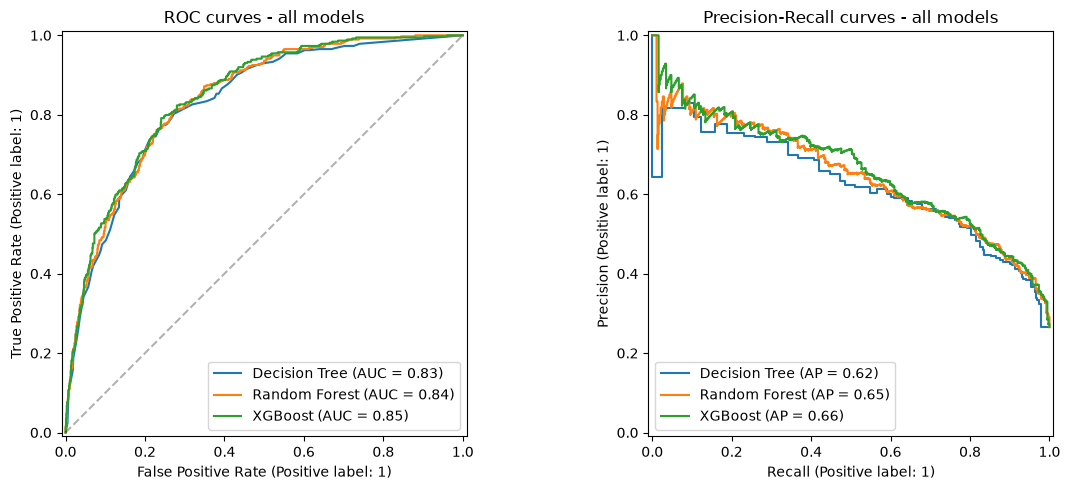

In [38]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
for name,model in models.items():
    pred = model.predict(X_test_enc)
    proba = model.predict_proba(X_test_enc)[:,1]
    RocCurveDisplay.from_predictions(y_test, proba, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[1], name=name)
axes[0].plot([0,1], [0,1], "k--", alpha=0.3)
axes[0].set_title("ROC curves - all models")
axes[1].set_title("Precision-Recall curves - all models")
plt.tight_layout()
plt.show()

## 19. Bundle the winning model into one pipeline

A `Pipeline` chains steps together into a single object: calling `.fit(X, y)` runs `preprocessor.fit_transform` then hands the result to the classifier automatically, and `.predict(X)` does the same at inference time. One object, one call, no risk of forgetting a step or applying it in the wrong order — the exact risk we'd otherwise carry into the Streamlit app.

We rebuild the preprocessor (same recipe as step 20) and the classifier (XGBoost, with the best hyperparameters from the search), wire them into a `Pipeline`, and fit it on the *raw* `X_train` — no manual encoding this time, the pipeline does that internally.

Then we predict on raw `X_test` and confirm the metrics match what we already saw in step 22. This isn't optional busywork: it's the check that the bundled version behaves identically to what we've been evaluating all along, before we trust it enough to save.

In [40]:
churn_pipeline = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(
          transformers=[
              ("num", "passthrough", numeric_cols),
              ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), categorical_cols)
          ],
        verbose_feature_names_out=False
    )),
    ("classifier", XGBClassifier(
        **random_search_xgb.best_params_,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])   

churn_pipeline.fit(X_train,y_train) # Raw (X_train)

pipe_pred = churn_pipeline.predict(X_test)
pipe_proba = churn_pipeline.predict_proba(X_test)[:, 1]

print(f"F1 (pipeline):       {f1_score(y_test, pipe_pred):.3f}")
print(f"F1 (manual):         {f1_score(y_test, y_pred_xgb):.3f}")
print("Match:", np.array_equal(pipe_pred, y_pred_xgb))

F1 (pipeline):       0.635
F1 (manual):         0.635
Match: True


## 20. Save the Model - with Metadata

`joblib.dump` is the standard way to save a fitted scikit-learn object (more efficient than plain `pickle` for objects holding NumPy arrays, which a fitted tree-based model does).

But a `.joblib` file alone is a black box six months from now: no record of what it is, how good it was, or what produced it. So we save a metadata JSON alongside it:

- `best_params`: from the winning search, so the run is reproducible
- `test_set_metrics` and the full `model_comparison` table: the evidence behind why XGBoost was chosen
- `sklearn_version` / `python_version`: a saved model can silently break on a different library version, so this is worth recording from day one
- `saved_at_utc`: when it was produced

This is a small step toward the kind of experiment tracking a tool like MLflow automates — worth knowing by hand once before reaching for the tool.

In [41]:
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)
model_path = MODELS_DIR / "churn_pipeline.joblib"
joblib.dump(churn_pipeline, model_path)

metadata = {
    "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    "model_type": "XGBoost (via sklearn pipeline : ColumnTransfromer + XGBClassifier)",
    "best_params": {k: (v.item() if hasattr(v,"item") else v) for k,v in random_search_xgb.best_params_.items()},
    "test_set_metrics": comparison.loc["XGBoost"].to_dict(),
    "model_comparison": comparison.to_dict(orient="index"),
    "random_state": RANDOM_STATE,
    "sklearn_version": sklearn.__version__,
    "python_version": platform.python_version()
}

metadata_path = MODELS_DIR / "churn_pipeline_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)
    
print("Saved:", model_path ,"and", metadata_path)
print(json.dumps(metadata ,indent=2))

Saved: models\churn_pipeline.joblib and models\churn_pipeline_metadata.json
{
  "saved_at_utc": "2026-09-27T21:52:53.321043+00:00",
  "model_type": "XGBoost (via sklearn pipeline : ColumnTransfromer + XGBClassifier)",
  "best_params": {
    "subsample": 1.0,
    "scale_pos_weight": 2.768561872909699,
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.01,
    "colsample_bytree": 0.6
  },
  "test_set_metrics": {
    "Precision (Churn)": 0.527,
    "Recall (Churn)": 0.799,
    "F1 (Churn)": 0.635,
    "ROC-AUC": 0.846,
    "PR-AUC": 0.659
  },
  "model_comparison": {
    "Decision Tree": {
      "Precision (Churn)": 0.517,
      "Recall (Churn)": 0.791,
      "F1 (Churn)": 0.626,
      "ROC-AUC": 0.831,
      "PR-AUC": 0.621
    },
    "Random Forest": {
      "Precision (Churn)": 0.531,
      "Recall (Churn)": 0.773,
      "F1 (Churn)": 0.63,
      "ROC-AUC": 0.841,
      "PR-AUC": 0.647
    },
    "XGBoost": {
      "Precision (Churn)": 0.527,
      "Recall (Churn)": 0.

## 21. SHAP : explain individual predictions

**SHAP** (SHapley Additive exPlanations) assigns each feature a signed contribution to *one specific* prediction, rooted in Shapley values from cooperative game theory: think of each feature as a "player" contributing to the outcome, and SHAP fairly splits credit for how far a prediction sits from the average.

For a tree-based model, `shap.TreeExplainer` computes these exactly by walking the actual tree structure, not by sampling or approximating.

Three views, each answering a different question:
1. **Global bar chart**: which features matter most overall — the SHAP version of step 16.
2. **Beeswarm plot**: same features, but now showing *direction*. Does high tenure push toward churn or away from it?
3. **Waterfall for one customer**: exactly why the model gave *this* customer their churn probability.

We explain the raw `XGBClassifier` inside the pipeline (`churn_pipeline.named_steps["classifier"]`), so we first need `X_test` in its encoded form, the same as what the classifier actually sees.

In [42]:
xgb_model = churn_pipeline.named_steps["classifier"]
preprocessor_fitted = churn_pipeline.named_steps["preprocessor"]

X_test_enc_shap = preprocessor_fitted.transform(X_test)
feature_names = preprocessor_fitted.get_feature_names_out()

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_enc_shap)
shap_values.feature_names = list(feature_names)

print(shap_values.shape)

(1409, 40)


### 21.1 Global view : bar chart and beeswarm 

- **Bar chart**: mean absolute SHAP value per feature — the overall ranking, comparable to step 16's `feature_importances_`.
- **Beeswarm**: one dot per customer per feature. Position on the x-axis is that feature's SHAP value for that customer (right = pushes toward churn, left = pushes away). Color is the feature's actual value (red = high, blue = low). If red dots cluster on the left for `tenure`, that means high tenure consistently pushes predictions *away* from churn — the kind of statement `feature_importances_` alone can't make.

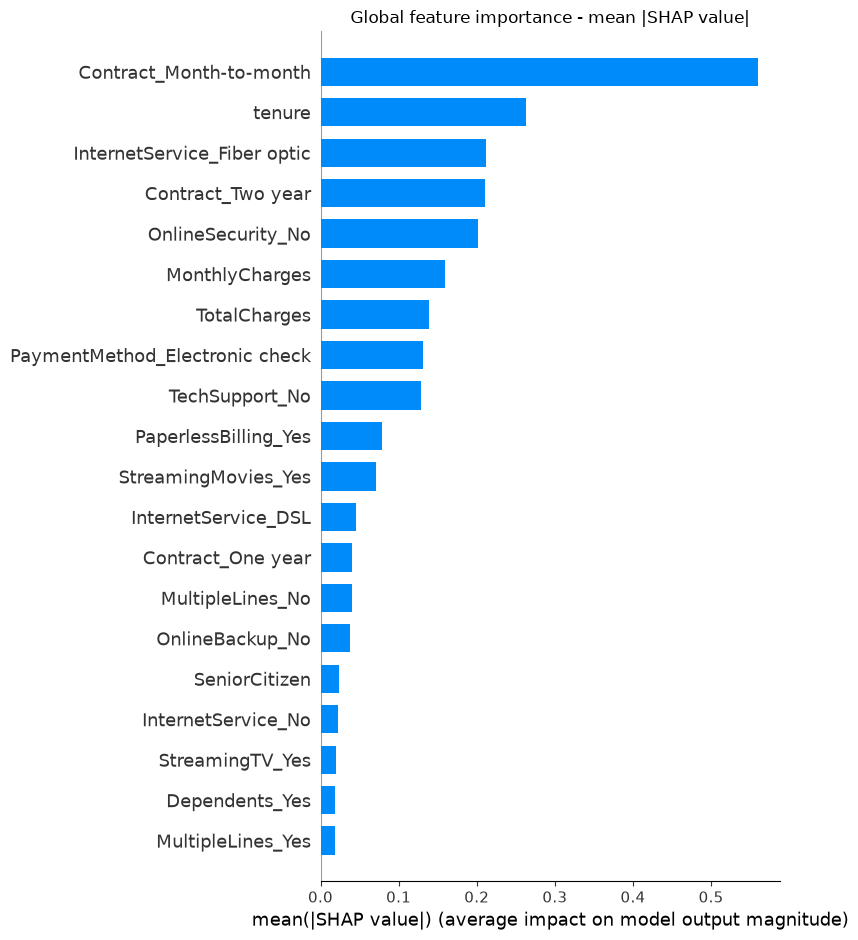

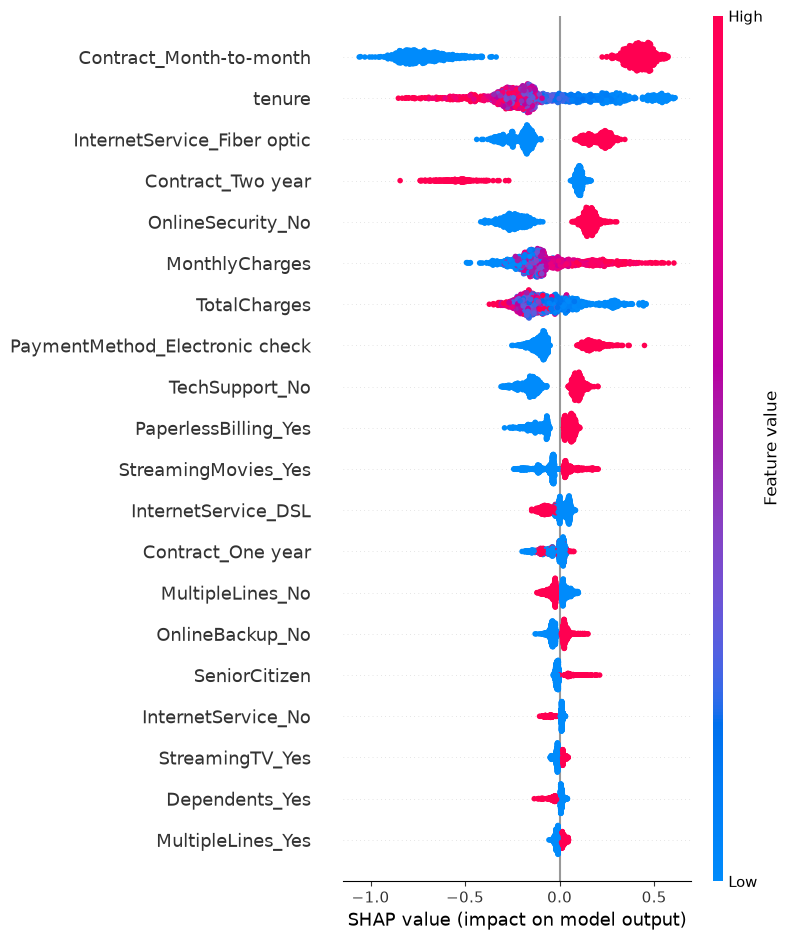

In [43]:
shap.summary_plot(shap_values, X_test_enc_shap, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Global feature importance - mean |SHAP value|")
plt.tight_layout()
plt.show()
shap.summary_plot(shap_values, X_test_enc_shap, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()



## 22. Explain one customer's prediction

We pick the customer the model is most confident will churn — the most compelling case to explain — using the same `predict_proba` you've already used throughout.

In [44]:
churn_proba_test = churn_pipeline.predict_proba(X_test)[:,1]
risk_idx = np.argmax(churn_proba_test)

print(f"Customer at position {risk_idx} - predicted churn probability {churn_proba_test[risk_idx]:.3f}")
X_test.iloc[risk_idx]

Customer at position 1090 - predicted churn probability 0.927


gender                          Male
SeniorCitizen                      1
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                  95.1
TotalCharges                    95.1
Name: 3380, dtype: object

### 22.2 Waterfall plot

Reads top to bottom:
- **`E[f(X)]`** at the bottom: the average model output over the background data — where every prediction starts before any feature is considered.
- Each bar is one feature's contribution for *this customer*: red pushes the prediction toward churn, blue pushes it away, and the bar's size is the size of that push.
- **`f(x)`** at the top: the final output for this customer, equal to the baseline plus every contribution added up.

One detail: `f(x)` is in **log-odds**, not a 0–1 probability, because that's the model's raw internal output before the sigmoid function converts it to the probability `predict_proba` reports. We'll convert it in the next cell so the two numbers can be compared directly.

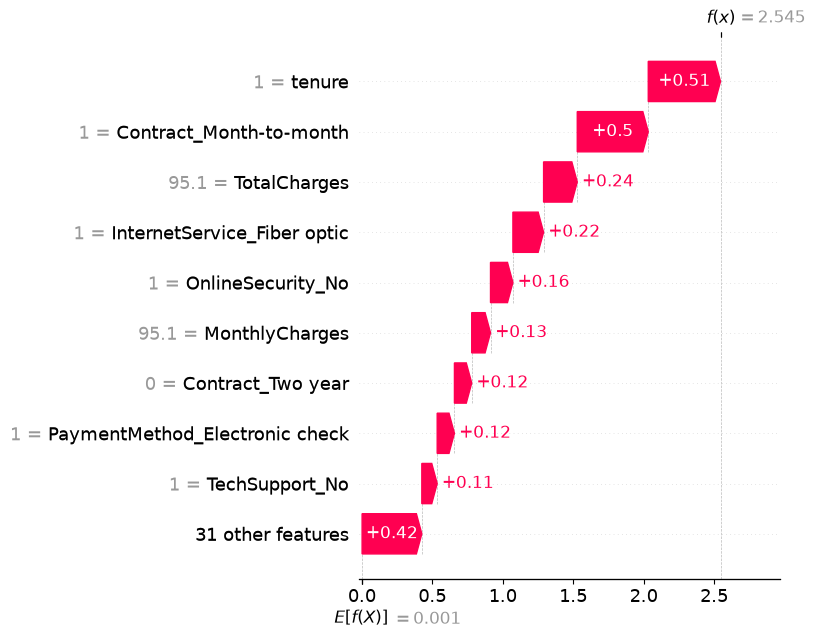

In [45]:
shap.plots.waterfall(shap_values[risk_idx], show=False)
plt.tight_layout()
plt.show()

### 22.3 Verify : SHAP reconstructs the exact prediction

This is the property that makes SHAP more than just a plot: `base_value + sum(all contributions)` reconstructs the model's exact raw output for this customer. Passing that through the sigmoid function (`scipy.special.expit`) should reproduce the same probability we printed in step 28, to the third decimal place.

In [47]:
raw_score = shap_values[risk_idx].base_values + shap_values[risk_idx].values.sum()
reconstructed_proba = expit(raw_score)

print(f"Reconstructed from SHAP: {reconstructed_proba:.3f}")
print(f"Model's predicted proba: {churn_proba_test[risk_idx]:.3f}")

Reconstructed from SHAP: 0.927
Model's predicted proba: 0.927


# 🏁 Conclusion

In this project, we built a complete machine learning solution for predicting **customer churn** using the Telco Customer Churn dataset. 📊

We followed an end-to-end machine learning workflow, including:

- 🧹 Data cleaning and preprocessing.
- 🔎 Exploratory data analysis to understand customer behavior and churn patterns.
- ⚙️ Feature engineering and categorical encoding.
- 🌳 Training a baseline Decision Tree model.
- 🔍 Hyperparameter tuning using cross-validation.
- 🌲 Training and tuning a Random Forest model.
- 🚀 Training and tuning an XGBoost model.
- 📊 Comparing the models using multiple classification metrics.
- 📉 Analyzing ROC-AUC and Precision-Recall performance.
- 🔬 Using SHAP to improve model interpretability.
- 💾 Saving the final selected model for future deployment.

The comparison demonstrates how different tree-based algorithms can produce different predictive results and how **hyperparameter tuning and cross-validation** can improve model performance.

Importantly, model evaluation was not based on accuracy alone. **Precision, Recall, F1-score, ROC-AUC, and PR-AUC** were also considered because churn is an imbalanced classification problem and correctly identifying customers who are likely to churn is particularly important. 🎯

## 🏆 Final Model

After comparing the tuned Decision Tree, Random Forest, and XGBoost models, the **selected final model is:**

> **[INSERT SELECTED MODEL HERE]**

The selected model will serve as the final machine learning model for the next stage of the project.

## 🚀 Next Step: Deployment

The final model provides a foundation for a practical customer-retention application.

In the next stage, the trained model can be integrated into a Python application and deployed through a **Streamlit interface**, allowing users to enter customer information and receive a churn prediction.

This will turn the machine learning workflow developed in the notebook into a more practical and user-friendly application. 💻✨